In [875]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [876]:
kaggle_data=pd.read_csv("Phishing_Email.csv",encoding="latin-1")
my_emails=pd.read_csv("my_emails.csv",encoding="latin-1")

In [877]:
kaggle_data

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email


In [878]:
my_emails

,Email Text,Label
0,"Hello, please submit your assignment by Friday...",0
1,Reminder: Our meeting is scheduled for tomorro...,0
2,Your subscription has been successfully renewe...,0
3,"Hi, we have updated our privacy policy. You ca...",0
4,Your order has been shipped and will arrive wi...,0
5,Please find attached the notes from today's le...,0
6,We have received your application and will get...,0
7,URGENT: Your account has been compromised. Ver...,1
8,You have been selected for an exclusive reward...,1
9,"Dear user, your account will be suspended unle...",1


In [879]:
kaggle_data["labels"]=kaggle_data["Email Type"].map({

"Phishing Email":1,
"Safe Email":0
})

In [880]:
kaggle_data

,Unnamed: 0,Email Text,Email Type,labels
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,2,re : equistar deal tickets are you still avail...,Safe Email,0
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1
...,...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email,1
18646,18647,request submitted : access request for anita ....,Safe Email,0
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email,0
18648,18649,press clippings - letter on californian utilit...,Safe Email,0


In [881]:
kaggle_data = kaggle_data.drop(columns=['Unnamed: 0'])

In [882]:
kaggle_data

,Email Text,Email Type,labels
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,re : equistar deal tickets are you still avail...,Safe Email,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1
...,...,...,...
18645,date a lonely housewife always wanted to date ...,Phishing Email,1
18646,request submitted : access request for anita ....,Safe Email,0
18647,"re : important - prc mtg hi dorn & john , as y...",Safe Email,0
18648,press clippings - letter on californian utilit...,Safe Email,0


In [883]:
kaggle_data=kaggle_data.drop(columns={
    "Email Type"
})

In [884]:
kaggle_data

,Email Text,labels
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1
...,...,...
18645,date a lonely housewife always wanted to date ...,1
18646,request submitted : access request for anita ....,0
18647,"re : important - prc mtg hi dorn & john , as y...",0
18648,press clippings - letter on californian utilit...,0


In [885]:
kaggle_data=kaggle_data.rename(columns={

'labels':'Labels(SE|PE)'
})

In [886]:
kaggle_data

,Email Text,Labels(SE|PE)
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1
...,...,...
18645,date a lonely housewife always wanted to date ...,1
18646,request submitted : access request for anita ....,0
18647,"re : important - prc mtg hi dorn & john , as y...",0
18648,press clippings - letter on californian utilit...,0


In [887]:
my_emails

,Email Text,Label
0,"Hello, please submit your assignment by Friday...",0
1,Reminder: Our meeting is scheduled for tomorro...,0
2,Your subscription has been successfully renewe...,0
3,"Hi, we have updated our privacy policy. You ca...",0
4,Your order has been shipped and will arrive wi...,0
5,Please find attached the notes from today's le...,0
6,We have received your application and will get...,0
7,URGENT: Your account has been compromised. Ver...,1
8,You have been selected for an exclusive reward...,1
9,"Dear user, your account will be suspended unle...",1


In [888]:
my_emails=my_emails.rename(columns={
 "Label":"Labels(SE|PE)"
})

In [889]:
my_emails

,Email Text,Labels(SE|PE)
0,"Hello, please submit your assignment by Friday...",0
1,Reminder: Our meeting is scheduled for tomorro...,0
2,Your subscription has been successfully renewe...,0
3,"Hi, we have updated our privacy policy. You ca...",0
4,Your order has been shipped and will arrive wi...,0
5,Please find attached the notes from today's le...,0
6,We have received your application and will get...,0
7,URGENT: Your account has been compromised. Ver...,1
8,You have been selected for an exclusive reward...,1
9,"Dear user, your account will be suspended unle...",1


In [890]:
kaggle_data["Email Text"].isnull().sum()

np.int64(16)

In [891]:
kaggle_data = kaggle_data[kaggle_data["Email Text"].notnull()]
kaggle_data=kaggle_data[kaggle_data["Email Text"].str.strip()!=""]
kaggle_data=kaggle_data[kaggle_data['Email Text'].str.lower() != "empty"]

In [892]:
import re

In [893]:
def process(text):
    text=text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text




In [894]:
kaggle_data["Email Text"] = kaggle_data["Email Text"].astype(str)

In [895]:
kaggle_data["Email Text"]=kaggle_data["Email Text"].apply(process)
my_emails["Email Text"] = my_emails["Email Text"].apply(process)

In [896]:
final_data=pd.concat([kaggle_data,my_emails],ignore_index=True)
final_data = final_data.sample(frac=1).reset_index(drop=True)

In [897]:
final_data=pd.concat([kaggle_data,my_emails,],ignore_index=True)

In [898]:
final_data

,Email Text,Labels(SE|PE)
0,re 6 1100 disc uniformitarianism re 1086 sex l...,0
1,the other side of galicismos galicismo is a sp...,0
2,re equistar deal tickets are you still availab...,0
3,hello i am your hot lil horny toy i am the one...,1
4,software at incredibly low prices 86 lower dra...,1
...,...,...
18113,you have 1 new quarantined inbound email view ...,0
18114,reminder your class has been rescheduled to mo...,0
18115,your password was successfully changed if this...,0
18116,we are conducting maintenance tonight services...,0


In [899]:
final_data.isna().sum()

Email Text       0
Labels(SE|PE)    0
dtype: int64

In [900]:
cont=final_data['Labels(SE|PE)'].value_counts()
cont

Labels(SE|PE)
0    11136
1     6982
Name: count, dtype: int64

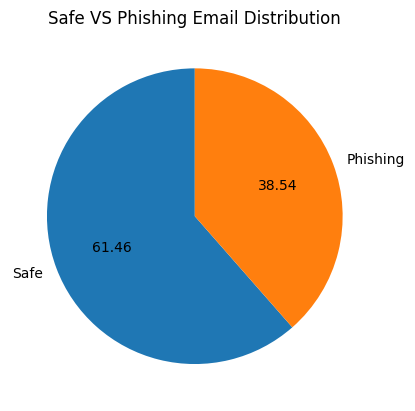

In [901]:
plt.pie(

cont,
labels=['Safe','Phishing'],
autopct="%0.2f",
startangle=90
)

plt.title("Safe VS Phishing Email Distribution")
plt.show()

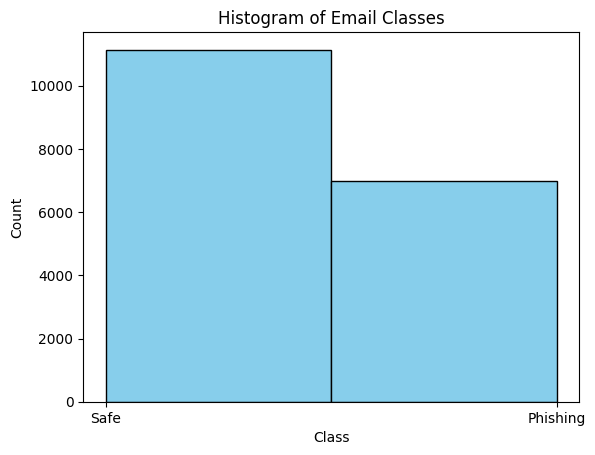

In [902]:

plt.hist(final_data['Labels(SE|PE)'], bins=2, color='skyblue', edgecolor='black')
plt.xticks([0, 1], ['Safe', 'Phishing'])
plt.title("Histogram of Email Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [903]:
final_data['num_char'] = final_data['Email Text'].apply(len)
final_data['num_words'] = final_data['Email Text'].apply(lambda x: len(x.split()))


In [904]:
final_data

,Email Text,Labels(SE|PE),num_char,num_words
0,re 6 1100 disc uniformitarianism re 1086 sex l...,0,919,180
1,the other side of galicismos galicismo is a sp...,0,443,73
2,re equistar deal tickets are you still availab...,0,1053,209
3,hello i am your hot lil horny toy i am the one...,1,528,113
4,software at incredibly low prices 86 lower dra...,1,387,64
...,...,...,...,...
18113,you have 1 new quarantined inbound email view ...,0,100,17
18114,reminder your class has been rescheduled to mo...,0,95,17
18115,your password was successfully changed if this...,0,86,13
18116,we are conducting maintenance tonight services...,0,77,10


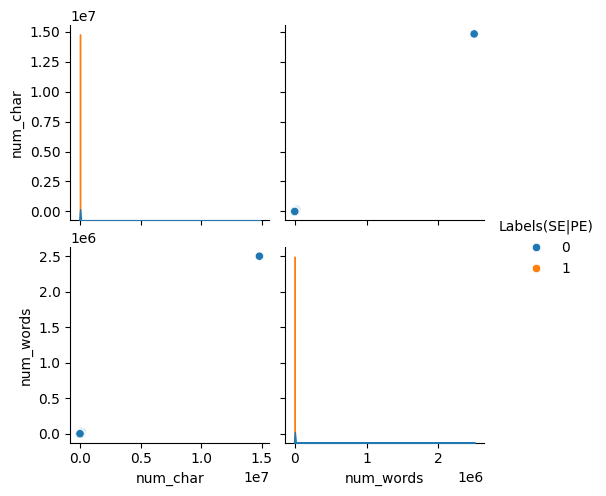

In [905]:
sns.pairplot(final_data, hue='Labels(SE|PE)')

In [906]:
threshold = final_data[['num_char', 'num_words']].quantile(0.99)

final_data = final_data[
    (final_data['num_char'] < threshold['num_char']) &
    (final_data['num_words'] < threshold['num_words'])
]

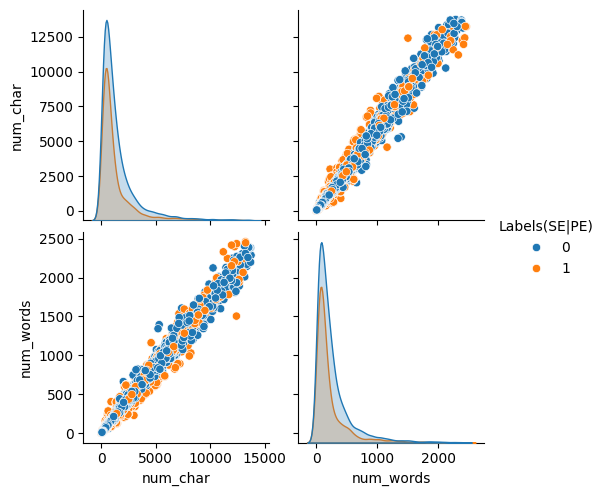

In [907]:
sns.pairplot(final_data, hue='Labels(SE|PE)')

In [908]:
x=final_data["Email Text"]
y=final_data["Labels(SE|PE)"]

In [909]:
from sklearn.model_selection import train_test_split

In [910]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [911]:
from sklearn.linear_model import LogisticRegression

In [912]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [913]:
tf=TfidfVectorizer(max_features=2000)

In [914]:
x_train=tf.fit_transform(x_train)
x_test=tf.transform(x_test)

In [915]:
model_logistic=LogisticRegression(C=2,max_iter=1000)

In [916]:
model_logistic.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [917]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report

In [918]:
y_prob = model_logistic.predict_proba(x_test)[:,1]
y_prob

array([0.04602405, 0.00992362, 0.00108865, ..., 0.83749719, 0.0945298 ,
       0.86189879], shape=(3584,))

In [919]:
threshold = 0.5
y_pred_logistic = (y_prob > threshold).astype(int)

In [920]:
print("Accuracy Score", + accuracy_score(y_test,y_pred_logistic))
print("Precision Score", + precision_score(y_test,y_pred_logistic))

Accuracy Score 0.9818638392857143
Precision Score 0.976418570375829


In [921]:
print(confusion_matrix(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))

[[2194   32]
 [  33 1325]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2226
           1       0.98      0.98      0.98      1358

    accuracy                           0.98      3584
   macro avg       0.98      0.98      0.98      3584
weighted avg       0.98      0.98      0.98      3584



In [922]:
# trying a different model for the improvement of accuracy and precsion 

In [923]:
# from sklearn.naive_bayes import MultinomialNB

In [924]:
# mlb=MultinomialNB()

In [925]:
# mlb.fit(x_train,y_train)

In [926]:
# y_pred_naive=mlb.predict(x_test)
# y_pred_naive

In [927]:
# print("Accuracy Score", + accuracy_score(y_test,y_pred_naive))
# print("Precision Score", + precision_score(y_test,y_pred_naive))

In [928]:
# print(confusion_matrix(y_test, y_pred_naive))
# print(classification_report(y_test, y_pred_naive))

In [929]:
# from sklearn.svm import LinearSVC

# model = LinearSVC()
# model.fit(x_train, y_train)

# y_pred_svm = model.predict(x_test)

In [930]:
# print("Accuracy Score", + accuracy_score(y_test,y_pred_svm))
# print("Precision Score", + precision_score(y_test,y_pred_svm))

In [931]:
# the following models were tried however the accuracy and precsion dropped so carrying on with the following model is not a good approach

In [933]:
def get_phishing_score(text, model, vectorizer):
    vector = vectorizer.transform([text])
    prob = model.predict_proba(vector)[0][1]
    percent = round(prob * 100, 2)
    
    if percent < 1:
        percent = 0.0
        
    return percent

# functions for determining the phishing and safe % amount for emails 

In [ ]:
score = get_phishing_score(
    "verify your account",
    model_logistic,
    tf
)

print(f"Phishing Probability: {score}%")

Phishing Probability: 98.1%
